In [1]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import itertools

In [ ]:
#function to apply LOESS smoothing
def loess_smooth(x, y, frac=0.3):
    sorted_indices = np.argsort(x)
    x_sorted = np.array(x)[sorted_indices]
    y_sorted = np.array(y)[sorted_indices]
    loess = sm.nonparametric.lowess(y_sorted, x_sorted, frac=frac)
    return loess[:, 0], loess[:, 1]

## Ankh VS BLOSUM

In [ ]:
def getting_plot(filename):
    natural = pd.read_csv(filename)

    #compute ProtT5 ratios
    prot_cols = ["CC", "DD", "POS", "SEQ", "SSP"]
    for col in prot_cols:
        natural[f"{col}_ANKH_Ratio"] = natural[f"{col} ANKH Better"] / (
            natural[f"{col} BLOSUM Better"] + natural[f"{col} ANKH Better"] + natural[f"{col} Equal"]
        )

    #compute BLOSUM ratios
    for col in prot_cols:
        natural[f"{col}_BLOSUM_Ratio"] = natural[f"{col} BLOSUM Better"] / (
            natural[f"{col} BLOSUM Better"] + natural[f"{col} ANKH Better"] + natural[f"{col} Equal"]
        )

    #initialize plot
    plt.figure(figsize=(8, 6))

    #generate color cycle and map ProtT5 colors
    color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
    color_map = {col: next(color_cycle) for col in prot_cols}

    #plot ProtT5 curves (solid lines)
    for col in prot_cols:

      if col == "DD":
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_ANKH_Ratio"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{'D'}}}$ Ankh", color=color_map[col])

      else:
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_ANKH_Ratio"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{col}}}$ Ankh", color=color_map[col])

    #plot BLOSUM curves (dotted lines) using the same colors
    for col in prot_cols:
      if col == "DD":
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_BLOSUM_Ratio"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{'D'}}}$ BLOSUM", color=color_map[col], linestyle=':')
      else:
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_BLOSUM_Ratio"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{col}}}$ BLOSUM", color=color_map[col], linestyle=':')

    #labels and title
    plt.xlabel("Amino Acid Identity")
    plt.ylabel("Winning Ratio")
    # plt.legend(loc='upper right', fontsize='small', ncol=2)
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small', ncol=1)
    plt.tight_layout()
    plt.savefig("wins_at_different_identities_ankh_vs_Blosum.pdf", format="pdf")
    plt.show()

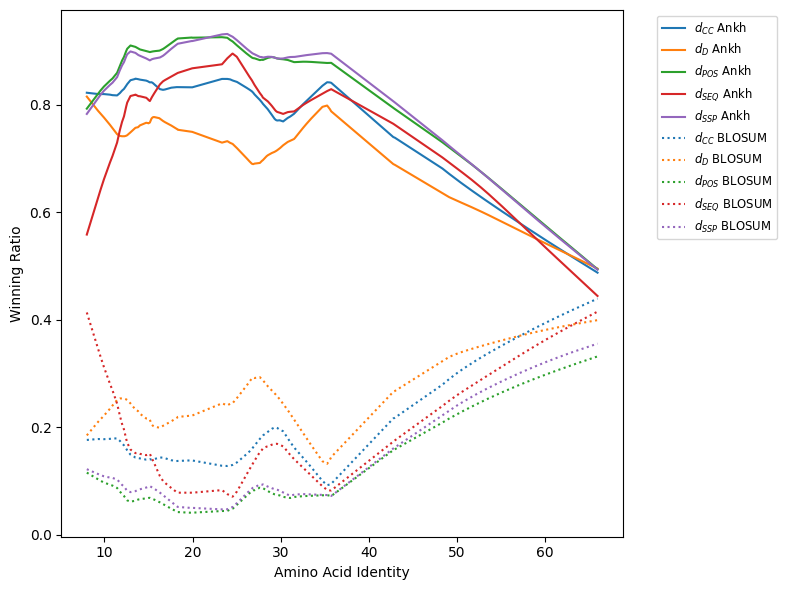

In [4]:
filename = "better_counts_combined.csv"
getting_plot(filename)

In [ ]:
def getting_plot(filename):
    natural = pd.read_csv(filename)

    pval_columns = ['CC P-Val', 'DD P-Val', 'POS P-Val', 'SEQ P-Val', 'SSP P-Val']
    natural = natural[natural[pval_columns].le(0.01).all(axis=1)]

    #compute ProtT5 ratios
    prot_cols = ["CC", "DD", "POS", "SEQ", "SSP"]

    #compute BLOSUM ratios
    for col in prot_cols:
        natural[f"{col}_BLOSUM_Average/ANKH_Average"] = natural[f"{col} BLOSUM Average"] / (
             natural[f"{col} ANKH Average"]
        )

    #initialize plot
    plt.figure(figsize=(8, 6))

    #generate color cycle and map ProtT5 colors
    color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
    color_map = {col: next(color_cycle) for col in prot_cols}

    #plot BLOSUM curves (dotted lines) using the same colors
    for col in prot_cols:
      if col == 'DD':
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_BLOSUM_Average/ANKH_Average"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{'D'}}}$", color=color_map[col])
      else:
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_BLOSUM_Average/ANKH_Average"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{col}}}$", color=color_map[col])

    plt.xlabel("Amino Acid Identity")
    plt.ylabel("BLOSUM Distance / Ankh Distance")
    plt.axhline(y=1, color='black', linestyle='--', linewidth=1)  #add horizontal line at y=1
    # plt.legend(loc='upper right', fontsize='small', ncol=1)
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small', ncol=1)
    plt.tight_layout()
    plt.savefig("BLOSUM_Average_over_ANKH_Average.pdf", format="pdf")
    plt.show()

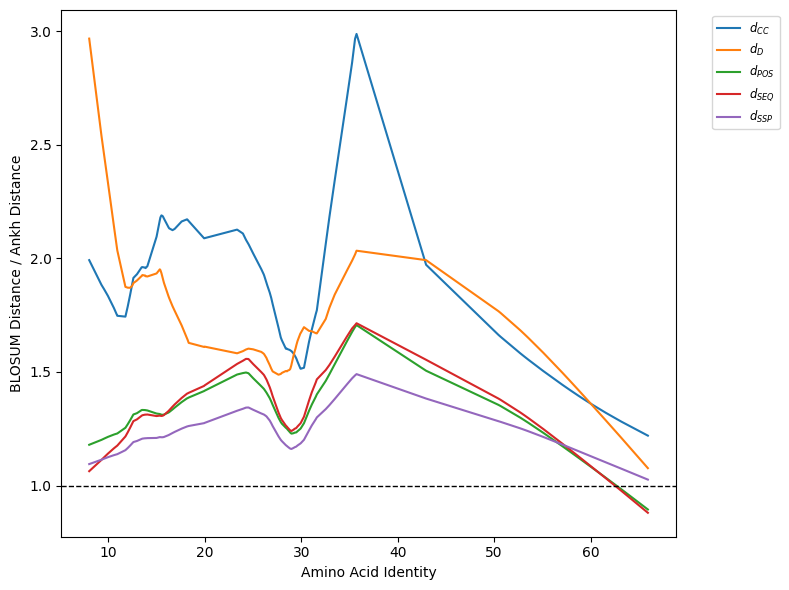

In [6]:
filename = "averages_combined.csv"
getting_plot(filename)

## Ankk VS ProtT5

In [ ]:
def getting_plot(filename):
    natural = pd.read_csv(filename)

    #compute ProtT5 ratios
    prot_cols = ["CC", "DD", "POS", "SEQ", "SSP"]
    for col in prot_cols:
        natural[f"{col}_ProtT5_Ratio"] = natural[f"{col} ProtT5 Better"] / (
            natural[f"{col} ANKH Better"] + natural[f"{col} ProtT5 Better"] + natural[f"{col} Equal"]
        )

    #compute BLOSUM ratios
    for col in prot_cols:
        natural[f"{col}_ANKH_Ratio"] = natural[f"{col} ANKH Better"] / (
            natural[f"{col} ANKH Better"] + natural[f"{col} ProtT5 Better"] + natural[f"{col} Equal"]
        )

    plt.figure(figsize=(8, 6))

    #generate color cycle and map ProtT5 colors
    color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
    color_map = {col: next(color_cycle) for col in prot_cols}

    #plot BLOSUM curves (dotted lines) using the same colors
    for col in prot_cols:
      if col == "DD":
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_ANKH_Ratio"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{'D'}}}$ Ankh", color=color_map[col])
      else:
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_ANKH_Ratio"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{col}}}$ Ankh", color=color_map[col])


    #plot ProtT5 curves (solid lines)
    for col in prot_cols:
      if col == 'DD':
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_ProtT5_Ratio"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{'D'}}}$ ProtT5", color=color_map[col], linestyle=':')
      else:
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_ProtT5_Ratio"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{col}}}$ ProtT5", color=color_map[col], linestyle=':')

    plt.xlabel("Amino Acid Identity")
    plt.ylabel("Winning Ratio")
    # plt.legend(loc='upper right', fontsize='small', ncol=2)
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small', ncol=1)
    plt.tight_layout()
    plt.savefig("wins_at_different_identities.pdf", format="pdf")
    plt.show()

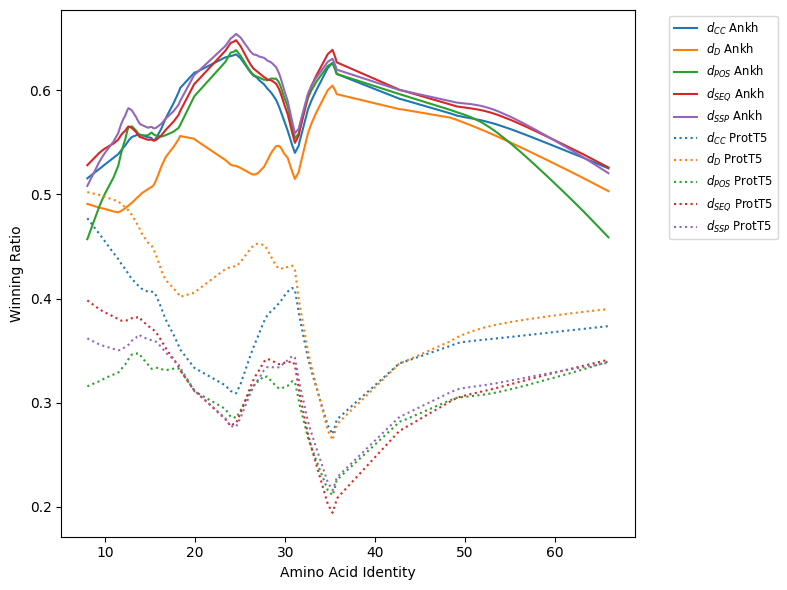

In [8]:
filename = "better_counts_combined.csv"
getting_plot(filename)

In [ ]:
def getting_plot(filename):
    natural = pd.read_csv(filename)

    pval_columns = ['CC P-Val', 'DD P-Val', 'POS P-Val', 'SEQ P-Val', 'SSP P-Val']
    natural = natural[natural[pval_columns].le(0.01).all(axis=1)]

    #compute ProtT5 ratios
    prot_cols = ["CC", "DD", "POS", "SEQ", "SSP"]

    #compute BLOSUM ratios
    for col in prot_cols:
        natural[f"{col}_ProtT5_Average/ANKH_Average"] = natural[f"{col} ProtT5 Average"] / (
             natural[f"{col} ANKH Average"]
        )

    plt.figure(figsize=(8, 6))

    #generate color cycle and map ProtT5 colors
    color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
    color_map = {col: next(color_cycle) for col in prot_cols}

    #plot BLOSUM curves (dotted lines) using the same colors
    for col in prot_cols:
      if col == 'DD':
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_ProtT5_Average/ANKH_Average"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{'D'}}}$", color=color_map[col])
      else:
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_ProtT5_Average/ANKH_Average"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{col}}}$", color=color_map[col])

    #labels and title
    plt.xlabel("Amino Acid Identity")
    plt.ylabel("ProtT5 Distance / Ankh Distance")
    plt.axhline(y=1, color='black', linestyle='--', linewidth=1)  # Add horizontal line at y=1
    # plt.legend(loc='upper right', fontsize='small', ncol=1)
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small', ncol=1)
    plt.tight_layout()
    plt.savefig("ProtT5_Average_over_ankh_Average.pdf", format="pdf")
    plt.show()

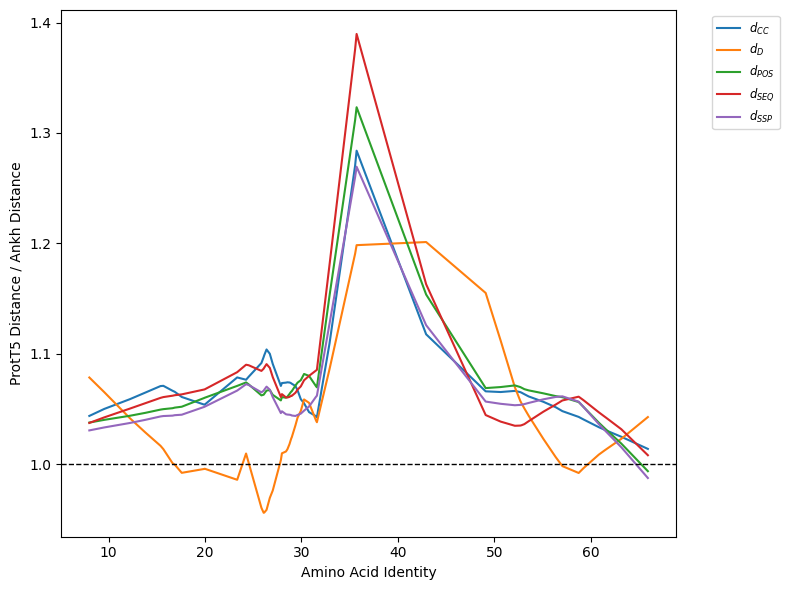

In [10]:
filename = "averages_combined.csv"
getting_plot(filename)

## Ankh VS Dedal

In [ ]:
def getting_plot(filename):
    natural = pd.read_csv(filename)

    prot_cols = ["CC", "DD", "POS", "SEQ", "SSP"]
    for col in prot_cols:
        natural[f"{col}_DEDAL_Ratio"] = natural[f"{col} DEDAL Better"] / (
            natural[f"{col} ANKH Better"] + natural[f"{col} DEDAL Better"] + natural[f"{col} Equal"]
        )

    for col in prot_cols:
        natural[f"{col}_ANKH_Ratio"] = natural[f"{col} ANKH Better"] / (
            natural[f"{col} ANKH Better"] + natural[f"{col} DEDAL Better"] + natural[f"{col} Equal"]
        )

    plt.figure(figsize=(8, 6))

    #generate color cycle and map ProtT5 colors
    color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
    color_map = {col: next(color_cycle) for col in prot_cols}

    for col in prot_cols:
      if col == "DD":
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_ANKH_Ratio"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{'D'}}}$ Ankh", color=color_map[col])
      else:
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_ANKH_Ratio"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{col}}}$ Ankh", color=color_map[col])

    for col in prot_cols:
      if col == 'DD':
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_DEDAL_Ratio"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{col}}}$ DEDAL", color=color_map[col], linestyle=':')
      else:
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_DEDAL_Ratio"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{col}}}$ DEDAL", color=color_map[col], linestyle=':')

    plt.xlabel("Amino Acid Identity")
    plt.ylabel("Winning Ratio")
    # plt.legend(loc='upper right', fontsize='small', ncol=2)
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small', ncol=1)
    plt.tight_layout()
    plt.savefig("wins_at_different_identities_DEDAL_VS_ANKH.pdf", format="pdf")
    plt.show()

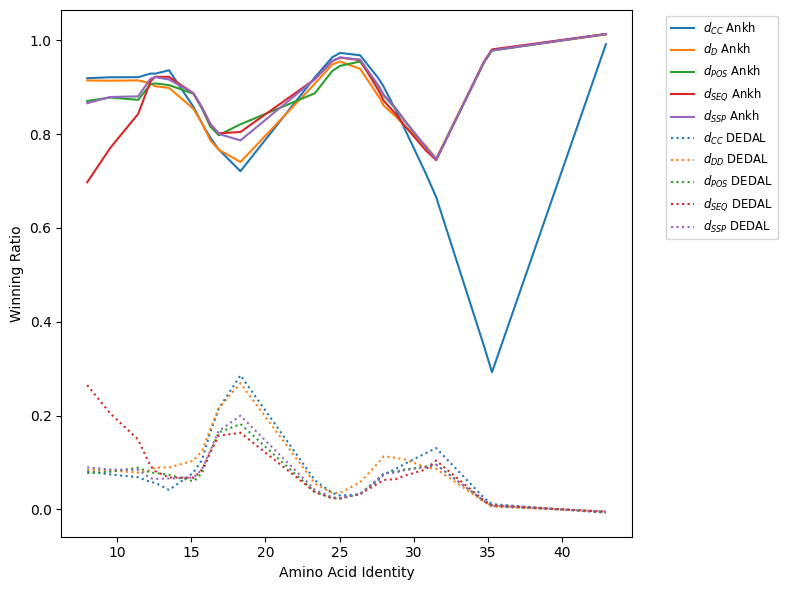

In [ ]:
filename = "better_counts_combined.csv"
getting_plot(filename)

In [ ]:
def getting_plot(filename):
    natural = pd.read_csv(filename)
    pval_columns = ['CC P-Val', 'DD P-Val', 'POS P-Val', 'SEQ P-Val', 'SSP P-Val']
    natural = natural[natural[pval_columns].le(0.01).all(axis=1)]

    prot_cols = ["CC", "DD", "POS", "SEQ", "SSP"]
    for col in prot_cols:
        natural[f"{col}_DEDAL_Average/ANKH_Average"] = natural[f"{col} DEDAL Average"] / (
             natural[f"{col} ANKH Average"]
        )

    plt.figure(figsize=(8, 6))

    #generate color cycle and map ProtT5 colors
    color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
    color_map = {col: next(color_cycle) for col in prot_cols}

    for col in prot_cols:
      if col == "DD":
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_DEDAL_Average/ANKH_Average"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{'D'}}}$", color=color_map[col])
      else:
        x_smooth, y_smooth = loess_smooth(natural["Average_Identity"], natural[f"{col}_DEDAL_Average/ANKH_Average"])
        plt.plot(x_smooth, y_smooth, label=f"$d_{{{col}}}$", color=color_map[col])

    plt.xlabel("Amino Acid Identity")
    plt.ylabel("DEDAL Distance / Ankh Distance")
    plt.axhline(y=1, color='black', linestyle='--', linewidth=1)  # Add horizontal line at y=1
    # plt.legend(loc='upper right', fontsize='small', ncol=1)
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small', ncol=1)
    plt.tight_layout()
    plt.savefig("DEDAL_Average_over_ankh_Average.pdf", format="pdf")
    plt.show()

In [ ]:
filename = "averages_combined.csv"
getting_plot(filename)